In [1]:
from google.colab import files
uploaded = files.upload()

Saving employee-attrition.csv to employee-attrition (1).csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [4]:
df = pd.read_csv("employee-attrition (1).csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
df.shape

(1470, 35)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [7]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [8]:
df = df.dropna()

In [9]:
df = df.drop_duplicates()

In [10]:
total_employees = df.shape[0]
print("Total Employees:", total_employees)

Total Employees: 1470


In [11]:
attrition_count = df[df["Attrition"] == "Yes"].shape[0]
print("Employees Left:", attrition_count)

Employees Left: 237


In [12]:
attrition_rate = (attrition_count / total_employees) * 100
print("Attrition Rate: {:.2f}%".format(attrition_rate))

Attrition Rate: 16.12%


In [13]:
dept_attrition = df.groupby("Department")["Attrition"].value_counts().unstack()
print(dept_attrition)

Attrition                No  Yes
Department                      
Human Resources          51   12
Research & Development  828  133
Sales                   354   92


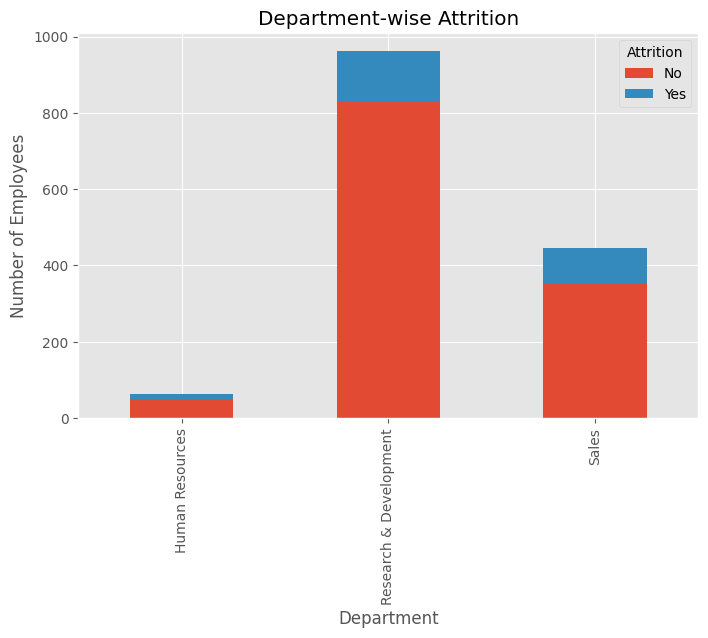

In [14]:
dept_attrition.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Department-wise Attrition")
plt.ylabel("Number of Employees")
plt.show()

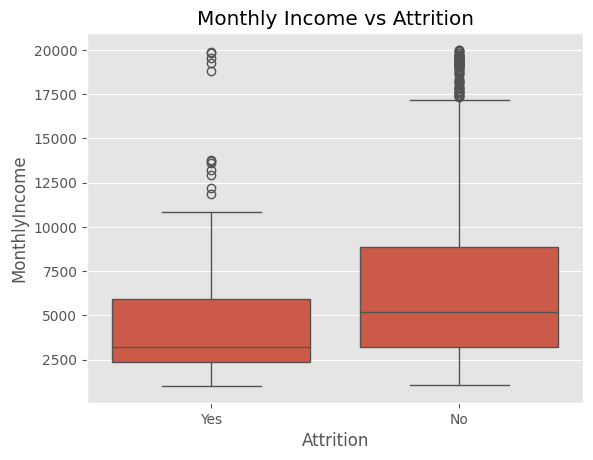

In [15]:
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)
plt.title("Monthly Income vs Attrition")
plt.show()

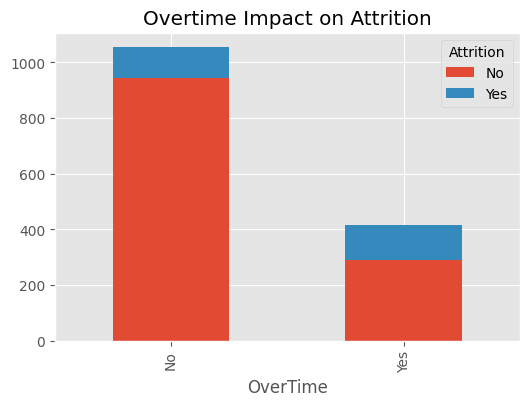

In [16]:
overtime_attrition = df.groupby("OverTime")["Attrition"].value_counts().unstack()
overtime_attrition.plot(kind="bar", stacked=True, figsize=(6,4))
plt.title("Overtime Impact on Attrition")
plt.show()

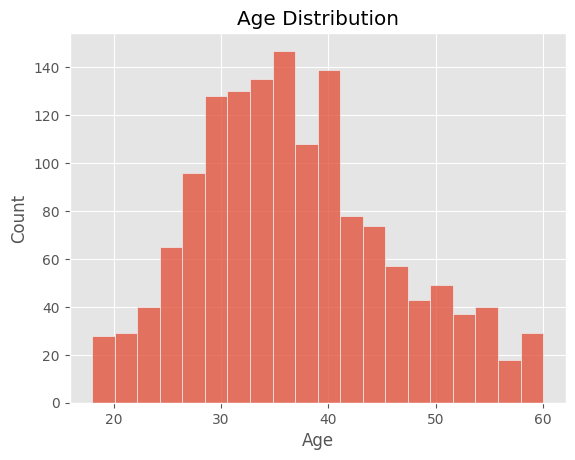

In [17]:
sns.histplot(df["Age"], bins=20)
plt.title("Age Distribution")
plt.show()

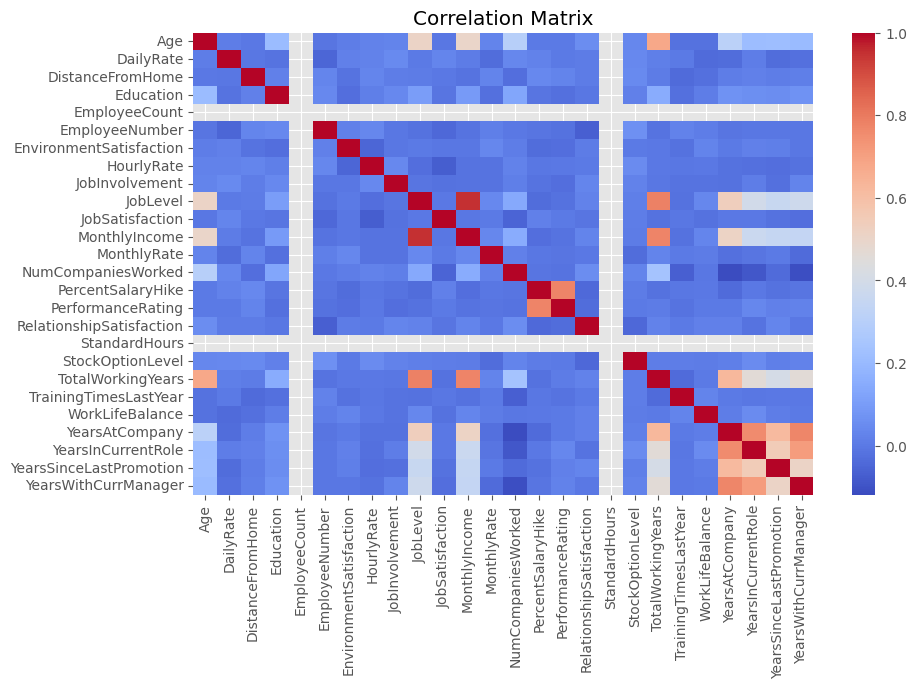

In [18]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [19]:
df.to_csv("HR_Cleaned_Data.csv", index=False)

In [20]:
files.download("HR_Cleaned_Data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

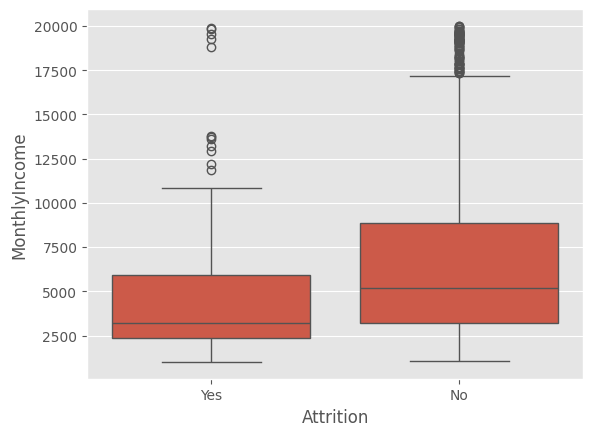

In [21]:
plt.figure()
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)
plt.savefig("salary_vs_attrition.png")
files.download("salary_vs_attrition.png")